# PARTE 1 - EXTRAÇÃO

In [72]:
from google.colab import files
uploaded = files.upload()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("academia_redfit.csv")
df

Saving academia_redfit.csv to academia_redfit (14).csv


,idade,sexo,frequencia_semanal_treino,tipo_atividade,tempo_medio_exercicio,minutos_totais_semana,preco_plano,possui_nutricionista,primeiro_PGC,ultimo_PGC,data_matricula,estado
0,48,Outro,7.0,Natação,45.3,317.1,188.47,Não,39.5,24.9,2021-07-28,Ativa
1,30,Outro,7.0,Yoga,98.1,686.7,198.07,Não,25.2,23.5,2020-12-28,Ativa
2,35,Masculino,5.0,Cardio,33.9,169.5,154.90,Não,27.2,11.4,2022-02-27,Ativa
3,43,Outro,3.0,Yoga,75.6,226.8,250.79,Sim,14.4,19.2,2022-12-01,Ativa
4,37,Masculino,0.0,CrossFit,114.0,0.0,168.02,Sim,21.5,18.1,2024-01-20,Sedentária
...,...,...,...,...,...,...,...,...,...,...,...,...
995,43,Feminino,0.0,Futebol,101.7,0.0,215.21,Não,31.1,32.4,2024-04-24,Sedentária
996,39,Outro,5.0,Futebol,78.0,390.0,269.34,Sim,38.8,31.8,2022-11-02,Ativa
997,25,Feminino,2.0,Natação,112.3,224.6,130.93,Não,23.8,28.4,2025-01-24,Ativa
998,24,Masculino,4.0,CrossFit,113.8,455.2,149.22,Sim,30.5,35.7,2020-12-03,Ativa


# PARTE 2 - TRANSFORMAÇÃO

In [73]:
df = df.copy()

df["sexo"] = df["sexo"].astype(str).str.strip().str.lower()
df["estado"] = df["estado"].astype(str).str.strip().str.lower()
df["tipo_atividade"] = df["tipo_atividade"].astype(str).str.strip().str.lower()

df["sexo"] = df["sexo"].replace({
    "masculino": "Masculino",
    "feminino": "Feminino",
    "outro": "Outro"
})

df["estado"] = df["estado"].replace({
    "ativa": "Ativa",
    "sedentária": "Sedentária",
    "sedentaria": "Sedentária"
})

df["tipo_atividade"] = df["tipo_atividade"].replace({
    "fut": "futebol",
    "soccer": "futebol",
    "futebol": "futebol",
    "swimming": "natacao",
    "natacao": "natacao",
    "natação": "natacao"
})

df["tipo_atividade"] = df["tipo_atividade"].str.title()

df["data_matricula"] = pd.to_datetime(df["data_matricula"], errors="coerce")

df["evolucao_pgc"] = df["primeiro_PGC"] - df["ultimo_PGC"]

df["imc_estimado"] = (
    df["ultimo_PGC"] / 2
    + df["idade"] / 10
    - df["frequencia_semanal_treino"] / 5
)

df["nivel_atividade"] = "Ativa"

df.loc[df["estado"] == "Sedentária", "nivel_atividade"] = "Sedentária"

df.loc[
    (df["estado"] == "Ativa") &
    (df["frequencia_semanal_treino"] >= 5) &
    (df["minutos_totais_semana"] >= 300),
    "nivel_atividade"
] = "Atleta"

df = df.dropna(subset=[
    "idade",
    "sexo",
    "estado",
    "tipo_atividade",
    "data_matricula",
    "primeiro_PGC",
    "ultimo_PGC",
    "frequencia_semanal_treino",
    "minutos_totais_semana",
    "imc_estimado",
    "nivel_atividade"
])

# PARTE 3 - CARGA

In [74]:
df.to_csv("academia_club4_limpo.csv", index=False)

from google.colab import files
files.download("academia_club4_limpo.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PARTE 4 - GRÁFICOS

### Durante a análise dos dados, foi observado que a categoria "Outro" na variável sexo apresentava frequência elevada, indicando possível inconsistência no conjunto de dados.

### Para evitar distorções na interpretação dos resultados, optou-se por considerar apenas os valores Masculino e Feminino nos gráficos que utilizam a variável sexo.

### Os dados originais não foram alterados, sendo aplicado apenas um filtro na etapa de visualização, mantendo a integridade do conjunto de dados para as demais análises.


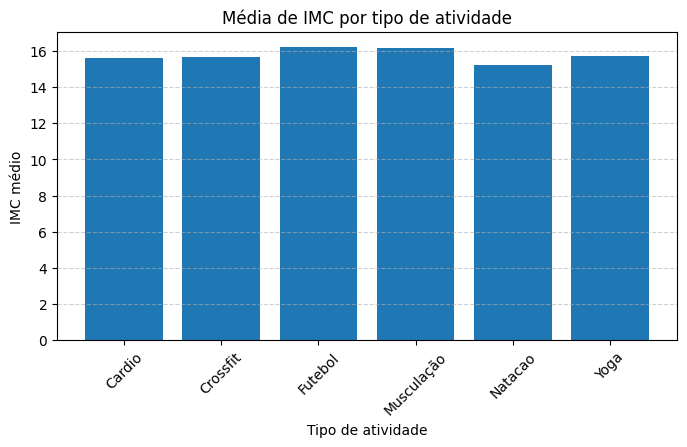

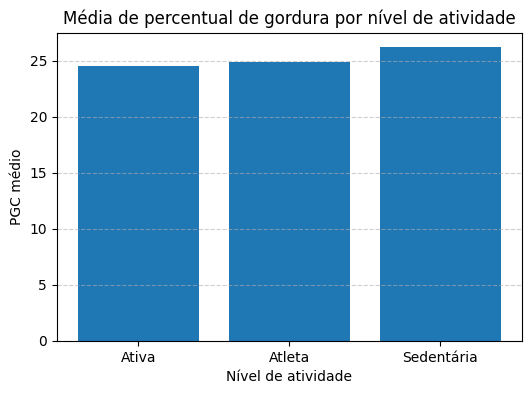

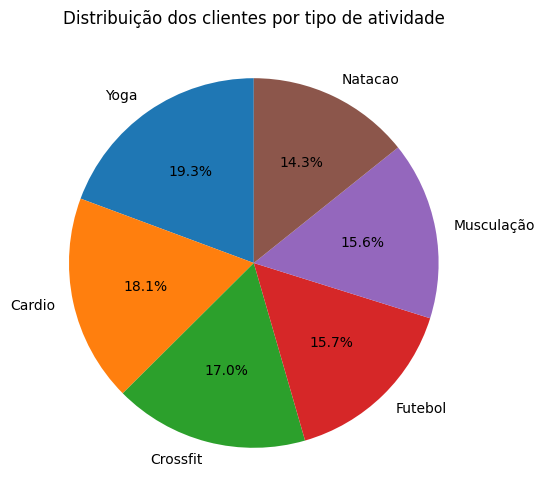

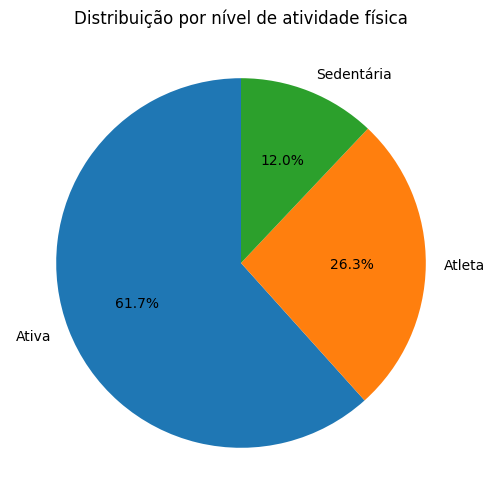

In [75]:
dados = df.groupby("tipo_atividade")["imc_estimado"].mean()

plt.figure(figsize=(8,4))

plt.bar(dados.index, dados.values)

plt.title("Média de IMC por tipo de atividade")
plt.xlabel("Tipo de atividade")
plt.ylabel("IMC médio")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


dados = df.groupby("nivel_atividade")["ultimo_PGC"].mean()

plt.figure(figsize=(6,4))

plt.bar(dados.index, dados.values)

plt.title("Média de percentual de gordura por nível de atividade")
plt.xlabel("Nível de atividade")
plt.ylabel("PGC médio")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


contagem = df["tipo_atividade"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    contagem,
    labels=contagem.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribuição dos clientes por tipo de atividade")

plt.ylabel("")

plt.show()


contagem = df["nivel_atividade"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    contagem,
    labels=contagem.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribuição por nível de atividade física")

plt.ylabel("")

plt.show()


# PARTE 5 - MACHINE LEARNING

In [77]:
df_ml = df.copy()

le_sexo = LabelEncoder()
le_tipo = LabelEncoder()
le_nivel = LabelEncoder()

df_ml["sexo"] = le_sexo.fit_transform(df_ml["sexo"])
df_ml["tipo_atividade"] = le_tipo.fit_transform(df_ml["tipo_atividade"])
df_ml["nivel_atividade"] = le_nivel.fit_transform(df_ml["nivel_atividade"])

X = df_ml[
    [
        "idade",
        "primeiro_PGC",
        "ultimo_PGC",
        "evolucao_pgc",
        "imc_estimado",
        "frequencia_semanal_treino",
        "sexo",
        "tipo_atividade"
    ]
]

y = df_ml["nivel_atividade"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)

print("Acurácia do modelo:", acuracia)

Acurácia do modelo: 0.875
